In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from scipy.stats import boxcox 
from statsmodels.tsa.seasonal import STL
from utils import load_data, check_stationarity
from plots import *

In [9]:
data = load_data()

/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [10]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

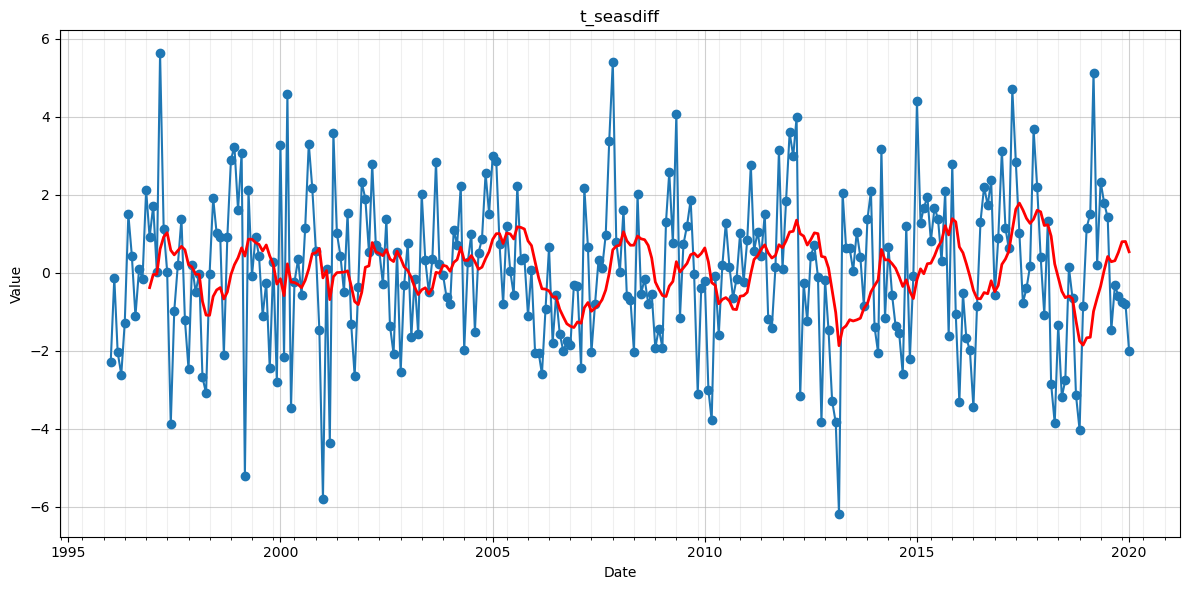

In [11]:
plot_time_series(data_sd, 'date', 't_seasdiff', ma_window=12)

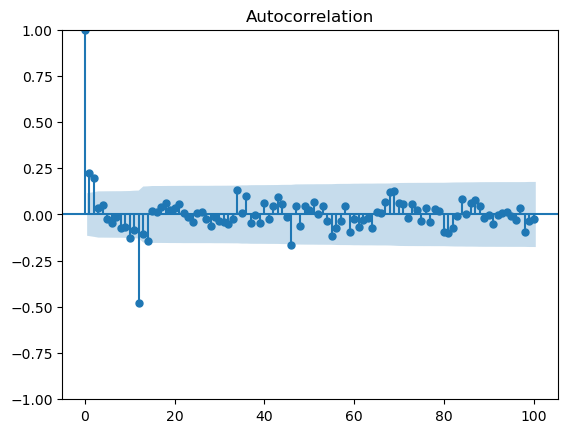

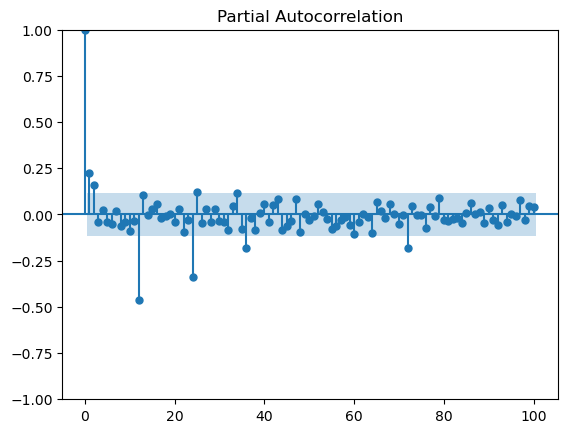

In [12]:
plot_acfs(data_sd, 't_seasdiff', lags=100)

In [13]:
from statsmodels.tsa.stattools import acf, pacf
y=data_sd["t_seasdiff"]
acf_vals = acf(y, nlags=40, fft=True)
pacf_vals = pacf(y, nlags=40, method="ywm")
print("ACF values:")
print(acf_vals)
print("\nPACF values:")
print(pacf_vals)

ACF values:
[ 1.          0.22276575  0.19989545  0.03384743  0.05330256 -0.02641575
 -0.04702443 -0.01494135 -0.07453389 -0.06661001 -0.12781762 -0.08564217
 -0.48082446 -0.10554175 -0.1422071   0.016506    0.01455207  0.04191135
  0.06073351  0.02216879  0.03493233  0.05687909  0.0073647  -0.01333421
 -0.04214666  0.00569386  0.01135275 -0.02248443 -0.06286985 -0.01313504
 -0.03603951 -0.04340223 -0.05002343 -0.02694267  0.13281249  0.00588777
  0.10204608 -0.04777113 -0.00287108 -0.04446014  0.0608922 ]

PACF values:
[ 1.00000000e+00  2.22765750e-01  1.58117382e-01 -4.19425756e-02
  2.47509894e-02 -4.16142614e-02 -5.01855930e-02  1.82964315e-02
 -6.46643773e-02 -4.24166177e-02 -8.83223630e-02 -3.55464102e-02
 -4.62952809e-01  1.03179380e-01 -4.76068970e-03  3.15409167e-02
  5.73422020e-02 -2.03833651e-02 -7.84879931e-03  9.81191595e-05
 -4.19514271e-02  2.88227948e-02 -9.46054391e-02 -2.80503767e-02
 -3.37580816e-01  1.23607796e-01 -4.48706694e-02  2.77238555e-02
 -4.04598498e-02  3